In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

import sys
import pickle

sys.path.append('..')
sys.path.append('../..')

from src.Environment.environment_v6 import MyModelSelectionEnv
from src.utils import *
from src.metrics import *
from src.Components.data_processing import data_process
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [2]:
import tf_agents.bandits.agents as bandit_agents
from tf_agents.metrics import tf_metrics
from tf_agents.trajectories import time_step as ts
from tf_agents.drivers import dynamic_step_driver
from tf_agents.environments import tf_py_environment
from tf_agents.networks import q_network
from tf_agents.bandits.replay_buffers import bandit_replay_buffer
from tf_agents.metrics import export_utils
from tf_agents.policies import policy_saver
from tf_agents.agents.random.random_agent import RandomAgent

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

### Importing Data and Setting Up the Environment

In [4]:
min_length = 0
max_length = 10000

filepath = '../datasets/gutentag/Anomaly4_v2.csv'
column_name = ['value', 'anomaly']
df = pd.read_csv(filepath, index_col=0, names=column_name, skiprows=1).dropna()
df = df.iloc[min_length:max_length]
data_np = df.to_numpy()

name = filepath.split('/')[-1]

data = data_np[min_length:max_length,0].astype(float)
label = data_np[min_length:max_length,1].astype(int)

In [5]:
train_path = '../data/synthetic/Anomaly4/Anomaly4_train.csv'

train_data = pd.read_csv(train_path, index_col=0)

In [6]:
test_data = df

list_threshold = [0.295060, 0.782376, 0.678237, 0.753004, 0.154873, 0.271028]

list_gtruth_test = test_data[['anomaly']].values.reshape(-1, 1)

list_gtruth_train = train_data[['anomaly']].values.reshape(-1, 1)

model_keys = ['norma', 'S2G', 'PCA', 'POLY', 'OCSVM', 'SAND_OFF']

### Preparing the Parameters

In [7]:
import pickle
import json

with open(f'../data/synthetic/Anomaly4/Anomaly4_tsfel_feats_window_20.pkl', 'rb') as file:
    loaded_feats = pickle.load(file)

with open(f'../data/synthetic/Anomaly4/Anomaly4_v2_scores.json', 'r') as file:
    loaded_score_dict = json.load(file)

with open(f'../data/synthetic/Anomaly4/Anomaly4_v2_labels.json', 'r') as file:
    loaded_label_dict = json.load(file)

with open(f'../data/synthetic/Anomaly4/Anomaly4_train_scores_labels.json', 'r') as file:
    loaded_train_dict = json.load(file)

loaded_feats = pd.concat(loaded_feats['feats_df'])
loaded_train_feats = pd.read_csv(f'../data/synthetic/Anomaly4/Anomaly4_train_feats.csv', index_col=0)

In [8]:
slicer = ['0_Power bandwidth', '0_Kurtosis', '0_Maximum frequency', '0_Average power', '0_Absolute energy', '0_Autocorrelation', '0_Peak to peak distance', '0_Fundamental frequency', '0_Skewness', '0_Neighbourhood peaks', '0_Variance', '0_Mean', '0_Root mean square', '0_Zero crossing rate']

In [9]:
loaded_feats = loaded_feats[slicer]
loaded_train_feats = loaded_train_feats[slicer]

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

loaded_feats = scaler.fit_transform(loaded_feats)
loaded_train_feats = scaler.fit_transform(loaded_train_feats)

loaded_feats = np.round(loaded_feats, decimals = 3)
loaded_train_feats = np.round(loaded_train_feats, decimals= 3)

In [11]:
loaded_score_dict['OCSVM'] = pd.Series(loaded_score_dict['OCSVM']).ewm(alpha=0.4).mean().to_list()
loaded_score_dict['AE'] = pd.Series(loaded_score_dict['AE']).ewm(alpha=0.4).mean().to_list()

In [12]:
score_list_test = [loaded_score_dict[key] for key in model_keys]
pred_list_test = [loaded_label_dict[key] for key in model_keys]

In [14]:
score_list_train = loaded_train_dict['score']
pred_list_train = loaded_train_dict['label']

In [15]:
import random
random.seed(42)

order_list = [i for i in range(len(loaded_train_feats) + 150)]

combined_train_list = list(zip(order_list, loaded_train_feats, list_gtruth_train, *score_list_train))
random.shuffle(combined_train_list)
shuffled_order, shuffled_train_feats, shuffled_train_gtruth, *shuffled_score_train_lol = zip(*combined_train_list)
shuffled_score_train = [list(sublist) for sublist in shuffled_score_train_lol]

In [16]:
shuffled_pred_train = []
for predder in pred_list_train:
    shupre = [predder[i] for i in shuffled_order]
    shuffled_pred_train.append(shupre)

In [17]:
train_env = MyModelSelectionEnv(train_data, list_thresholds=list_threshold, list_gtruth=shuffled_train_gtruth, subsequence=loaded_train_feats, list_predicted_score=shuffled_score_train, list_predicted_label=shuffled_pred_train, window_size=20)
train_environment = tf_py_environment.TFPyEnvironment(train_env) # Converts the PyEnvironment to TFEnvironment

In [18]:
EPSILON = 0.1
LAYERS = (50, 50, 50)
LR = 0.005

#TRAINING_LOOPS = 500
steps_per_loop = 1
async_steps_per_loop = 3

network = q_network.QNetwork(
          input_tensor_spec=train_environment.time_step_spec().observation,
          action_spec=train_environment.action_spec(),
          fc_layer_params=LAYERS,
      )

In [19]:

eps_agent = bandit_agents.neural_epsilon_greedy_agent.NeuralEpsilonGreedyAgent(action_spec=train_environment.action_spec(), time_step_spec=train_environment.time_step_spec(), reward_network=network, optimizer=tf.compat.v1.train.AdamOptimizer(learning_rate=LR),
        epsilon=EPSILON,
        emit_policy_info='predicted_rewards_mean',
        info_fields_to_inherit_from_greedy=['predicted_rewards_mean'])

eps_agent.initialize()

### Replay Buffers and Drivers

In [21]:
data_spec = eps_agent.policy.trajectory_spec

In [23]:
def get_replay_buffer(
    data_spec, batch_size, steps_per_loop, async_steps_per_loop
):
  """Return a `TFUniformReplayBuffer` for the given `agent`."""
  return bandit_replay_buffer.BanditReplayBuffer(
      data_spec=data_spec,
      batch_size=batch_size,
      max_length=steps_per_loop * async_steps_per_loop,
  )

In [24]:
replay_buffer = get_replay_buffer(
      data_spec, 8, steps_per_loop, async_steps_per_loop
  )

In [25]:
# Observers

step_metric = tf_metrics.EnvironmentSteps()
metrics = [
      tf_metrics.NumberOfEpisodes(), # Counts the number of episodes in the environment
      tf_metrics.AverageEpisodeLengthMetric(batch_size=train_environment.batch_size),   # Metric to compute the average episode length
      tf_metrics.AverageReturnMetric(batch_size=train_environment.batch_size) # Metric to compute the average return
  ]

add_batch_fn = replay_buffer.add_batch # Adds a batch of items on the replay buffer

observers = [add_batch_fn, step_metric] # + metrics # List of observers for the driver

In [26]:
driver = dynamic_step_driver.DynamicStepDriver(
      env=train_environment,
      policy=eps_agent.collect_policy,
      num_steps=steps_per_loop*train_environment.batch_size,
      observers=observers,
  )

In [27]:
# Replay Buffer Values

"""
    The .as_dataset method creates and returns a dataset as entries from the buffer.

    A single entry from the dataset is the result of the following pipeline:

    - Sample sequences from the underlying data store
    - (Optional) Process them with 'sequence_preprocess_fn'
    - (Optional) Split them into subsequences of length num_steps
    - (Optional) Batch them into batches of size 'sample_batch_size'

    In practice, this pipeline is executed in parallel as much as possible if num_parallel_calls != 1.

    
"""
driver.run()

dataset_it = iter(
        replay_buffer.as_dataset(
            sample_batch_size=8,
            num_steps=1,
            single_deterministic_pass=True,
        )
    )

In [29]:
def set_expected_shape(experience, num_steps):
  """Sets expected shape."""

  def set_time_dim(input_tensor, steps):
    tensor_shape = input_tensor.shape.as_list()
    if len(tensor_shape) < 2:
      raise ValueError(
          'input_tensor is expected to be of rank-2, but found otherwise: '
          f'input_tensor={input_tensor}, tensor_shape={tensor_shape}'
      )
    tensor_shape[1] = steps
    input_tensor.set_shape(tensor_shape)

  tf.nest.map_structure(lambda t: set_time_dim(t, num_steps), experience)

In [30]:
def training_loop(train_step, metrics):

    print(train_step)
    driver.run()
     
    batch_size = driver.env.batch_size
    dataset_it = iter(
        replay_buffer.as_dataset(
            sample_batch_size=batch_size,
            num_steps=1,
            single_deterministic_pass=False,
        )
    )

    meter = driver.observers[1:]
    for batch_id in range(async_steps_per_loop):
      experience, unused_buffer_info = dataset_it.get_next()
      set_expected_shape(experience, 1)
      loss_info = eps_agent.train(experience)

      export_utils.export_metrics(
          step=train_step * async_steps_per_loop + batch_id,
          metrics=meter,
          loss_info=loss_info,
      )

    replay_buffer.clear()

In [ ]:
for i in range(1, 248):

    training_loop(train_step=i, metrics=metrics)

In [32]:
policy = eps_agent.policy

In [ ]:
policy.trainable_variables

### Evaluating the Policy

In [ ]:
test_data = test_data.reset_index()
test_data

In [38]:
test_env = MyModelSelectionEnv(test_data, list_thresholds=list_threshold, list_gtruth=list_gtruth_test, subsequence=loaded_feats, list_predicted_score=score_list_test, list_predicted_label=pred_list_test, window_size=20)
test_environment = tf_py_environment.TFPyEnvironment(test_env) # Converts the PyEnvironment to TFEnvironment

In [ ]:
test_end = 1248
policy_state = policy.get_initial_state(batch_size=test_environment.batch_size)

act = np.array([1, 1, 1, 1, 1, 1, 1, 1])

obs = test_environment.step(act)

for step in range(test_end):
    print(step)
    policy_return = policy.action(obs, policy_state)
    act = policy_return.action
    policy_state = policy_return.state
    test_environment._apply_action(act)

In [40]:
score_list, label_list, act_list = test_environment._environment_values()

In [41]:
score_np = np.array(score_list)
label_np = np.array(label_list)
act_np = np.array(act_list)

In [ ]:
# Trained Policy Steps in Test Environment

act = 0
policy_state = policy.get_initial_state(batch_size=1)
act_list = []
score_list = []
subseq = test_env.subsequences
test_end = 9979
label_list = []

aa = test_environment.reset()

for step in range(test_end):

    time_step = test_environment.step(act)
    policy_return = policy.action(time_step, policy_state)
    act = policy_return.action.numpy()
    _, label, scr = test_env._apply_action(act[0])
    label_list.append(label)
    score_list.append(scr)
    print(test_env.pointer)
    policy_state = policy_return.state
    act_list.append(act)

In [43]:
score_np = np.array(score_list)
label_np = np.array(label_list)
uni_val, uni_counts = np.unique(label_np, return_counts=True)
print(uni_val, uni_counts)
print(test_data['anomaly'].value_counts())

[0 1] [9734  250]
anomaly
0    9400
1     600
Name: count, dtype: int64


In [44]:
test_end = 9984
sample_gtruth = test_data['anomaly'].iloc[10:test_end+10]
gtruth_np = sample_gtruth.to_numpy()
print(gtruth_np.shape, score_np.shape)
rg_pr, rg_rc, rg_f1, rg_prauc, adjusted_y_pred, tresold = adjusted_precision_recall_f1_auc(gtruth_np, score_np)
print(f'Model: MAB Neural Epsilon Greedy Point Adjusted F1: {rg_f1:.4f}, Point Adjusted AUCpr: {rg_prauc:.4f}')

(9984,) (9984,)
Model: MAB Neural Epsilon Greedy Point Adjusted F1: 0.9174, Point Adjusted AUCpr: 0.8614


In [47]:
adjusted_pred2 = adjust_predicts(score=score_np, label=(sample_gtruth>0), threshold=None, pred=label_np, calc_latency=False)

In [49]:
a_f1, a_prec, a_rec, *_ = f1_score(gtruth_np, adjusted_pred2)

print(a_f1)

0.9113454407697443


In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
sample_gtruth = test_data['anomaly'].iloc[10:test_end+10]
prec = precision_score(sample_gtruth, label_np)
recall = recall_score(sample_gtruth, label_np)
f1 = f1_score(sample_gtruth, label_np)
rock = roc_auc_score(sample_gtruth, score_np)
ap = average_precision_score(sample_gtruth, score_np)

print(f'Precision Score: {prec:.4f}  Recall: {recall:.4f}  f1_score: {f1:.4f} roc_auc: {rock} Average Precision {ap}')

Precision Score: 0.9061  Recall: 0.9167  f1_score: 0.9114 roc_auc: 0.6186713199772663 Average Precision 0.384759055218118


In [64]:
gtruth_base = test_data['anomaly'].iloc[0:10000].to_numpy()

for model, scr in loaded_score_dict.items():
    sample_scr = np.array(scr)
    rg_pr, rg_rc, rg_f1, rg_prauc, adjusted_y_pred, threy = adjusted_precision_recall_f1_auc(gtruth_base, sample_scr)
    print(f'Model: {model} Point Adjusted F1: {rg_f1:.4f}, Point Adjusted AUCpr: {rg_prauc:.4f}')

Model: IF Point Adjusted F1: 0.9592, Point Adjusted AUCpr: 0.8732
Model: S2G Point Adjusted F1: 0.7686, Point Adjusted AUCpr: 0.6443
Model: norma Point Adjusted F1: 0.7395, Point Adjusted AUCpr: 0.5381
Model: PCA Point Adjusted F1: 0.8204, Point Adjusted AUCpr: 0.7156
Model: SAND_OFF Point Adjusted F1: 0.7576, Point Adjusted AUCpr: 0.6240
Model: POLY Point Adjusted F1: 0.7619, Point Adjusted AUCpr: 0.5946
Model: OCSVM Point Adjusted F1: 0.6608, Point Adjusted AUCpr: 0.5814
Model: AE Point Adjusted F1: 0.6508, Point Adjusted AUCpr: 0.5814
Model: LOF Point Adjusted F1: 0.9486, Point Adjusted AUCpr: 0.7579


In [65]:
gtruth_base = test_data['anomaly'].iloc[0:105000].to_numpy()

i = 0

for label, scr in zip(pred_list_test, score_list_test):
    i += 1
    prec = precision_score(gtruth_base, label)
    recall = recall_score(gtruth_base, label)
    f1 = f1_score(gtruth_base, label)
    rock = roc_auc_score(gtruth_base, scr)
    ap = average_precision_score(gtruth_base, scr)

    print(f'Model {i}: Precision Score: {prec:.4f}  Recall: {recall:.4f}  f1_score: {f1:.4f}  ROC AUC: {rock:.4f}  Average Precision: {ap:.4f}')

Model 1: Precision Score: 0.7293  Recall: 0.7500  f1_score: 0.7395  ROC AUC: 0.7196  Average Precision: 0.5056
Model 2: Precision Score: 0.7133  Recall: 0.8333  f1_score: 0.7686  ROC AUC: 0.6057  Average Precision: 0.1202
Model 3: Precision Score: 0.9054  Recall: 0.7500  f1_score: 0.8204  ROC AUC: 0.6197  Average Precision: 0.4116
Model 4: Precision Score: 0.8889  Recall: 0.6667  f1_score: 0.7619  ROC AUC: 0.5651  Average Precision: 0.3618
Model 5: Precision Score: 0.5874  Recall: 0.6667  f1_score: 0.6245  ROC AUC: 0.5277  Average Precision: 0.0977
Model 6: Precision Score: 0.7653  Recall: 0.7500  f1_score: 0.7576  ROC AUC: 0.7069  Average Precision: 0.5079


In [51]:
act_np = np.array(act_list)
uniq_act, uniq_count = np.unique(act_np, return_counts=True)
print(uniq_act, uniq_count)

[0 1 2 3 4 5] [ 186  160 9158  163  169  148]


In [52]:
downsampled_act = act_np[::2]
downsampled_act.shape

(4992,)

In [53]:
act_np = act_np.reshape(-1,)

In [ ]:
window_size = 10  # Define window size
max_jumps = []  # Store positions of maximum jumps
votes = np.zeros(len(act_np))  # Initialize votes

# Step 2: Create Windows
for i in range(0, len(act_np) - window_size + 1, 50):
    window = act_np[i:i+window_size]

    jumps = np.diff(window)
    max_jump_index = np.argmax(np.abs(jumps))
    max_jump_position = i + max_jump_index
    
    # Step 4: Vote System
    votes[max_jump_position] += 1
    max_jumps.append(max_jump_position)

"""# Step 5: Visualization
plt.figure(figsize=(10, 6))
plt.plot(data, label='Data')
plt.scatter(max_jumps, data[max_jumps], color='red', s=100, label='Maximum Jumps')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Maximum Jumps within Windows')
plt.legend()
plt.grid(True)
plt.show()"""

In [ ]:
# smoothing out noise
from scipy.signal import medfilt

window_size = 3
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(30, 10))

# action_smooth = np.convolve(act_np, np.ones(window_size), 'valid') / window_size
action_smooth = medfilt(act_np, kernel_size=window_size)


axs[0].plot(action_smooth)
axs[1].plot(act_np)
plt.show()

In [55]:
segments = [(250, 300, 'red'), (470, 520, 'green'), (900, 950, 'blue'), (2500, 2600, 'orange'), (3400, 3450, 'yellow'), (4300, 4400, '#9467bd'), (5200, 5250, 'yellow'), (6500, 6550, 'red'), (7200, 7250, '#9467bd'), (8700, 8750, 'blue')]

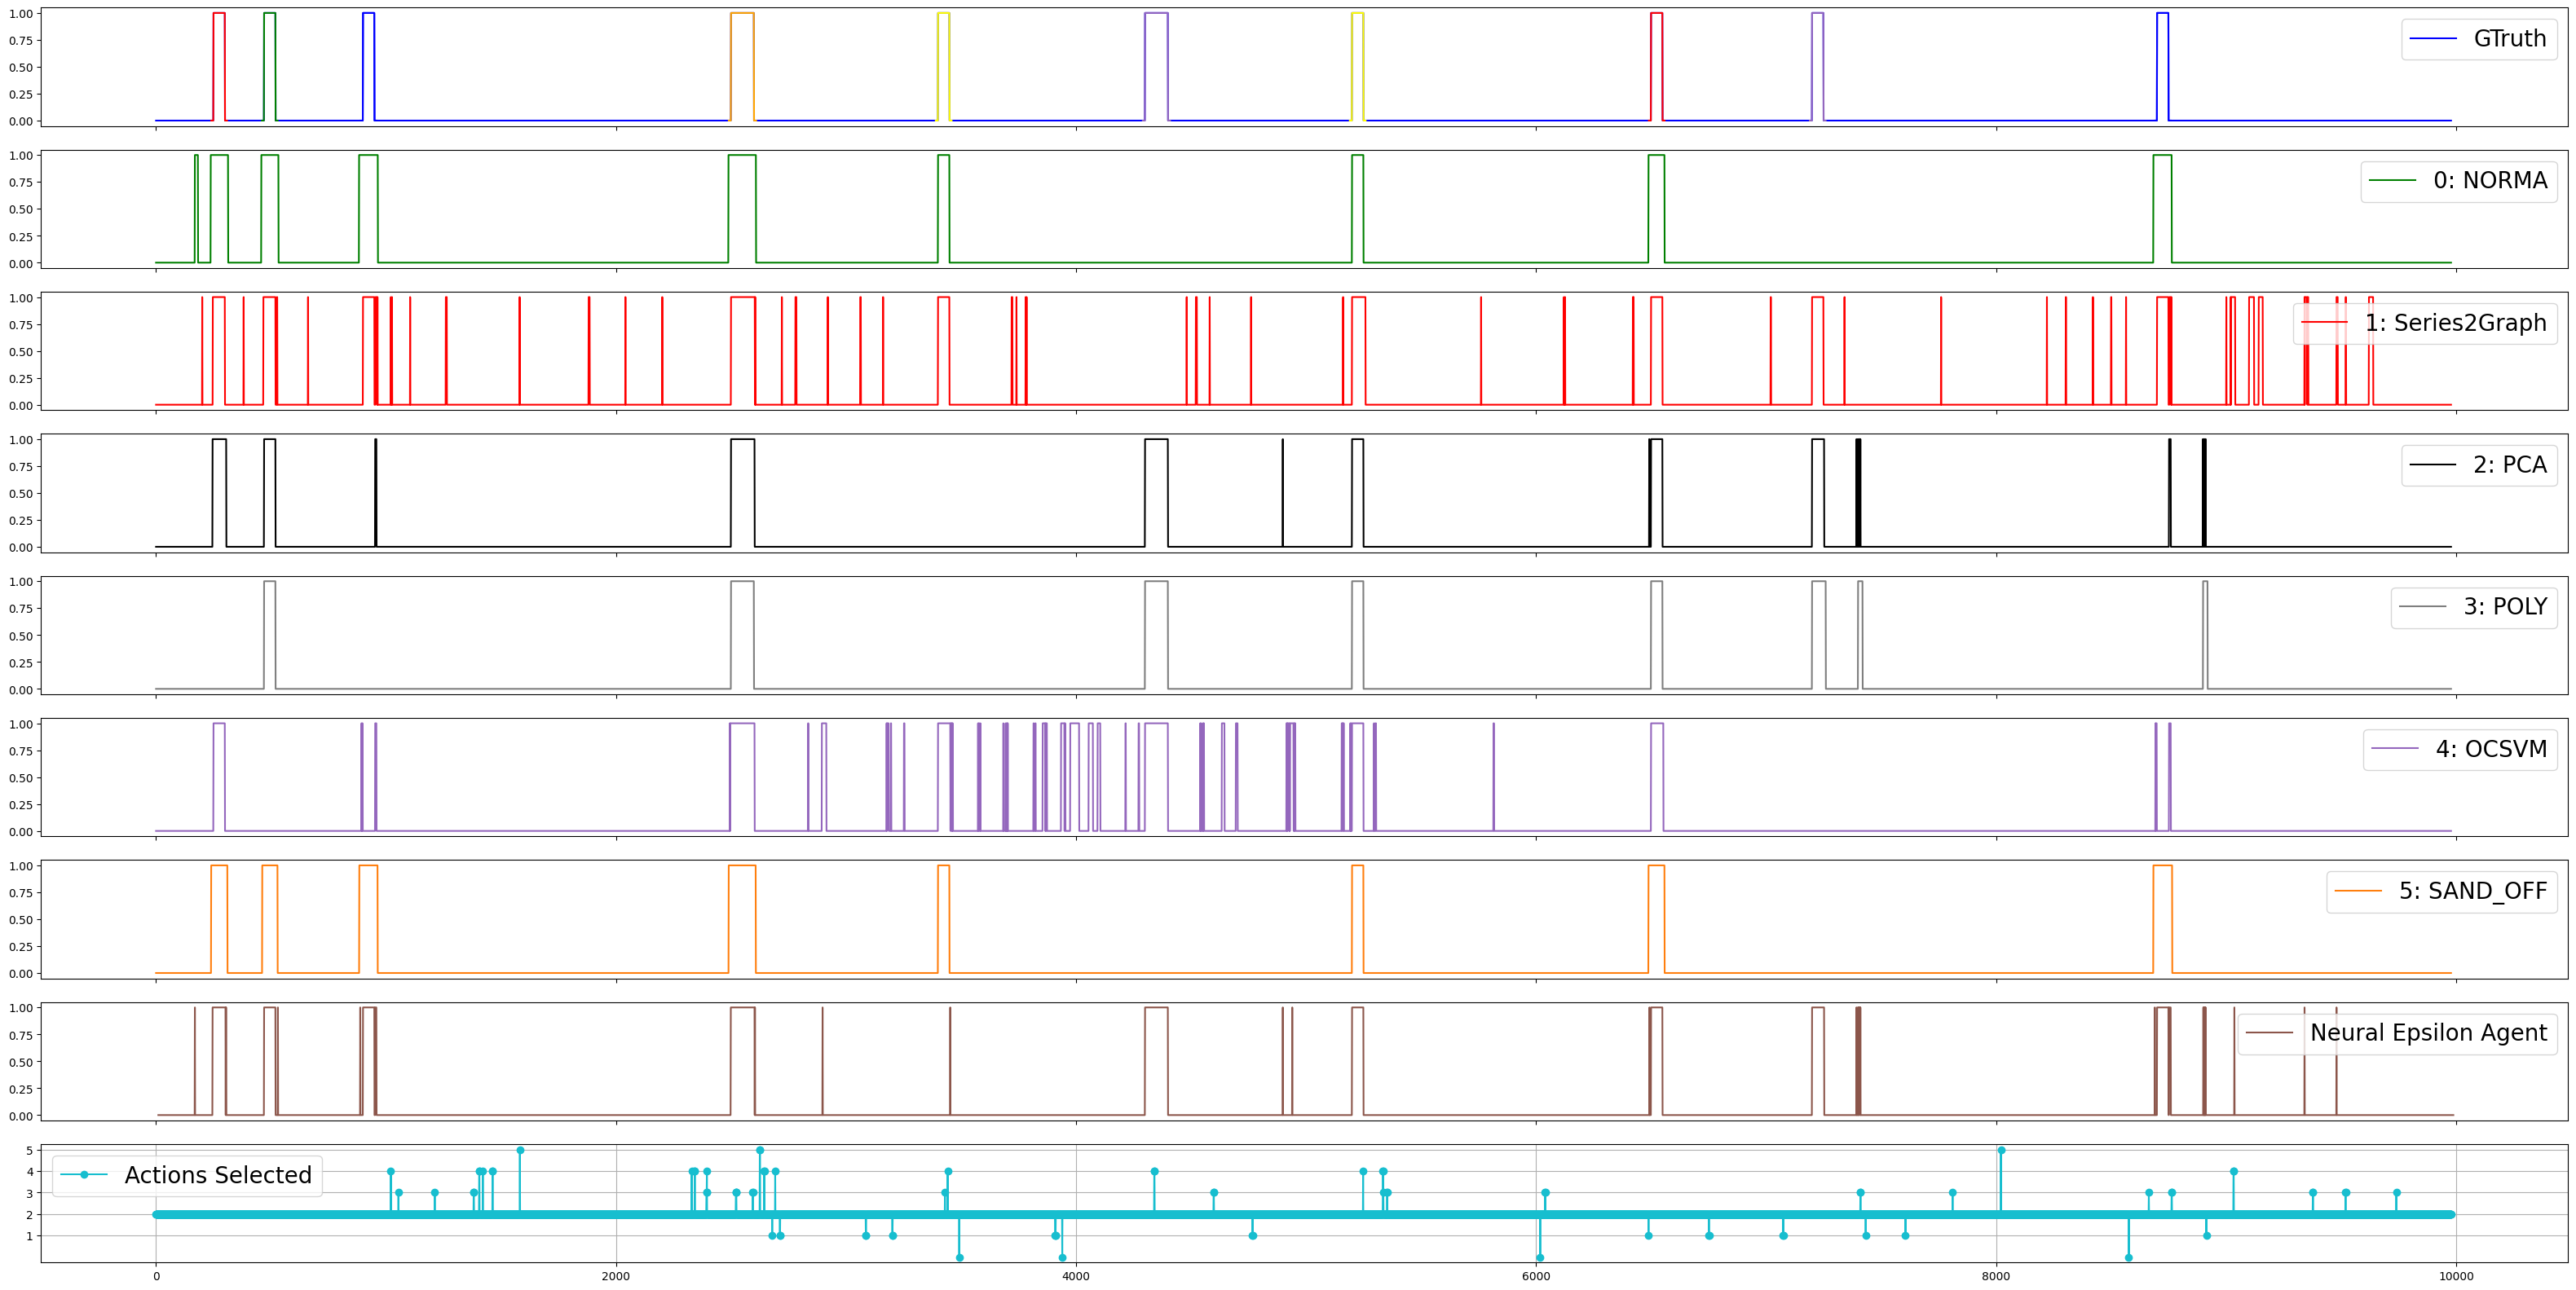

In [57]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(9, 1, sharex=True, figsize=(40, 20))


min_length = 0
max_length = 9979
index = range(min_length, max_length)
index_mab = range(min_length + 10, max_length + 10)

axs[0].plot(index, list_gtruth_test[min_length:max_length], color='blue', label='GTruth')
for start, end, color in segments:
    axs[0].plot(index[start - 10:end + 10], list_gtruth_test[start - 10:end + 10], color=color)

axs[1].plot(index, loaded_label_dict['norma'][min_length:max_length], color = 'green', label = '0: NORMA')
axs[2].plot(index, loaded_label_dict['S2G'][min_length:max_length], color = 'red', label = '1: Series2Graph')
axs[3].plot(index, loaded_label_dict['PCA'][min_length:max_length], color = 'black', label = '2: PCA')
axs[4].plot(index, loaded_label_dict['POLY'][min_length:max_length], color = '#7f7f7f', label = '3: POLY')
axs[5].plot(index, loaded_label_dict['OCSVM'][min_length:max_length], color = '#9467bd',label = '4: OCSVM')
axs[6].plot(index, loaded_label_dict['SAND_OFF'][min_length:max_length], color = '#ff7f0e',label = '5: SAND_OFF')
axs[7].plot(index_mab, adjusted_pred2[min_length:max_length], color = '#8c564b', label = 'Neural Epsilon Agent')
axs[8].plot(index, action_smooth[min_length:max_length], color = '#17becf', marker = 'o', linestyle = '-', label = 'Actions Selected')

axs[8].set_yticks(range(1, 6))
axs[8].set_yticklabels(range(1, 6))
axs[8].grid(True)

axs[0].legend(fontsize=20)
axs[1].legend(fontsize=20)
axs[2].legend(fontsize=20)
axs[3].legend(fontsize=20)
axs[4].legend(fontsize=20)
axs[5].legend(fontsize=20)
axs[6].legend(fontsize=20)
axs[7].legend(fontsize=20)
axs[8].legend(fontsize=20)

In [ ]:
model_keys = ['IF', 'S2G', 'norma', 'PCA', 'SAND_OFF', 'POLY', 'OCSVM', 'AE']

In [ ]:
import matplotlib.pyplot as plt


fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9) = plt.subplots(9, 1, sharex=True, figsize=(30, 10))
index = range(39848)
index_mab = range(50, 39848 + 50)

ax1.plot(index_mab, sample_gtruth, color='blue', label='GTruth')
ax7.plot(index, pred_list_test[5], color='red', label='POLY')
ax2.plot(index, pred_list_test[0], color = 'green', label = 'IForest')
ax3.plot(index, pred_list_test[1], color = 'yellow', label = 'Series2Graph')
ax4.plot(index, pred_list_test[2], color = 'black', label = 'NORMA')
ax5.plot(index, pred_list_test[3], color = 'pink', label = 'PCA')
ax6.plot(index, pred_list_test[4], color = 'pink', label = 'SAND_OFF')
ax8.plot(index, pred_list_test[6], color = 'pink', label = 'OCSVM')
#ax9.plot(index, pred_list_test[7], color = 'pink', label = 'AE')
ax9.plot(index, label_np, label = 'MAB')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax3.legend(loc='upper left')
ax4.legend(loc='upper right')
ax5.legend(loc='upper left')
ax6.legend(loc='upper right')
ax7.legend()
ax8.legend()
ax9.legend()
#ax10.legend()


plt.show()

### Random Agent

In [ ]:
action_spec = test_environment.action_spec()
time_step_spec = test_environment.time_step_spec()
random_agent = RandomAgent(action_spec=action_spec, time_step_spec=time_step_spec)

In [ ]:
aa = test_environment.reset()
action = random_agent.policy.action(aa)
aacctt = action.action.numpy()
type(aacctt[0])

In [ ]:
time_step = test_environment.reset()
random_act_list = []
random_score_list = []
random_label_list = []
random_action_list = []

aa = test_environment.reset()

for i in range(9975):

    action = random_agent.policy.action(aa)
    act = action.action.numpy()
    aa = test_environment.step(action.action)
    _, label, scr = test_env._apply_action(act[0])
    random_score_list.append(scr)
    random_label_list.append(label)
    random_action_list.append(act)

    print(i)

In [ ]:
random_score_np = np.array(random_score_list)
random_label_np = np.array(random_label_list)

In [ ]:
test_end = 9975
sample_gtruth = test_data['anomaly'].iloc[10:test_end+10]
gtruth_np = sample_gtruth.to_numpy()
print(gtruth_np.shape, random_score_np.shape)
rg_pr, rg_rc, rg_f1, rg_prauc, adjusted_y_pred_randn, _ = adjusted_precision_recall_f1_auc(gtruth_np, random_score_np)
print(f'Random Agent Point Adjusted F1: {rg_f1:.4f}, Point Adjusted AUCpr: {rg_prauc:.4f}')

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(20, 10))
index = range(9975)
index_mab = range(10, 9985)

ax1.plot(index_mab, sample_gtruth, color='blue', label='GTruth')
ax2.plot(index, adjusted_y_pred_randn, label = 'Random Agent')

In [ ]:
act_np = np.array(random_action_list)
uniq_act, uniq_count = np.unique(act_np, return_counts=True)
print(uniq_act, uniq_count)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

prec = precision_score(gtruth_np, random_label_np)
recall = recall_score(gtruth_np, random_label_np)
f1 = f1_score(gtruth_np, random_label_np)
rock = roc_auc_score(gtruth_np, random_label_np)

print(f'Precision Score: {prec:.4f}  Recall: {recall:.4f}  f1_score: {f1:.4f} roc_auc: {rock}')

In [ ]:
average_precision_score(gtruth_np, random_score_np)